Saved comparison plot to ../plots/compare_monopoles.png


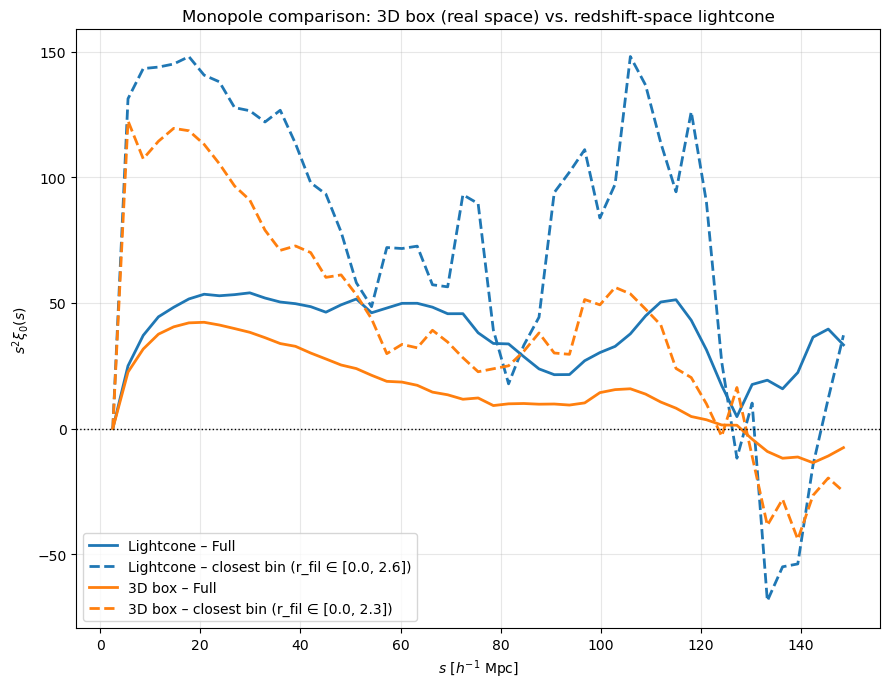

In [1]:
"""
Compare monopoles from 3D box (real‑space) and redshift‑space lightcone analyses.
Monopole files are stored in separate subdirectories: lightcone/ and 3dbox/
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import glob

# ---------------------------
# CONFIGURATION
# ---------------------------
# Base directory containing the subfolders
monopoles_base = "../data/monopoles/"
lightcone_dir = os.path.join(monopoles_base, "lightcone")
box3d_dir     = os.path.join(monopoles_base, "3dbox")

# Output plot file
output_plot = "../plots/compare_monopoles.png"

# ---------------------------
# HELPER FUNCTIONS
# ---------------------------
def load_monopole(filepath):
    """Load s and xi0 from a monopole .npz file."""
    data = np.load(filepath)
    s = data['s']
    xi0 = data['xi0']
    # Also get metadata if available
    dfil_min = data.get('dfil_min', None)
    dfil_max = data.get('dfil_max', None)
    return s, xi0, dfil_min, dfil_max

def find_closest_bin(files):
    """From a list of bin monopole files, return the one with smallest dfil_min."""
    best_file = None
    best_dfmin = np.inf
    for f in files:
        _, _, dfmin, _ = load_monopole(f)
        if dfmin is not None and dfmin < best_dfmin:
            best_dfmin = dfmin
            best_file = f
    return best_file

def split_full_bin(files):
    """Separate full sample files from bin files."""
    full = [f for f in files if "full" in f]
    bin  = [f for f in files if "bin" in f and not "full" in f]
    return full, bin

# ---------------------------
# MAIN
# ---------------------------
def main():
    # Check that directories exist
    if not os.path.exists(lightcone_dir):
        print(f"Warning: Lightcone directory not found: {lightcone_dir}")
        lightcone_files = []
    else:
        lightcone_files = glob.glob(os.path.join(lightcone_dir, "*.npz"))

    if not os.path.exists(box3d_dir):
        print(f"Warning: 3D box directory not found: {box3d_dir}")
        box3d_files = []
    else:
        box3d_files = glob.glob(os.path.join(box3d_dir, "*.npz"))

    if not lightcone_files and not box3d_files:
        print("No monopole files found in either directory. Exiting.")
        return

    # Separate full and bin for each
    lc_full, lc_bin = split_full_bin(lightcone_files)
    box_full, box_bin = split_full_bin(box3d_files)

    # Find closest bin for each analysis
    lc_closest = find_closest_bin(lc_bin) if lc_bin else None
    box_closest = find_closest_bin(box_bin) if box_bin else None

    # Prepare data for plotting
    data_to_plot = []

    # Lightcone full
    if lc_full:
        s, xi0, _, _ = load_monopole(lc_full[0])
        data_to_plot.append((s, xi0, 'Lightcone – Full', '-', 'C0'))

    # Lightcone closest bin
    if lc_closest:
        s, xi0, dfmin, dfmax = load_monopole(lc_closest)
        data_to_plot.append((s, xi0, f'Lightcone – closest bin (r_fil ∈ [{dfmin:.1f}, {dfmax:.1f}])', '--', 'C0'))

    # 3D box full
    if box_full:
        s, xi0, _, _ = load_monopole(box_full[0])
        data_to_plot.append((s, xi0, '3D box – Full', '-', 'C1'))

    # 3D box closest bin
    if box_closest:
        s, xi0, dfmin, dfmax = load_monopole(box_closest)
        data_to_plot.append((s, xi0, f'3D box – closest bin (r_fil ∈ [{dfmin:.1f}, {dfmax:.1f}])', '--', 'C1'))

    if not data_to_plot:
        print("No monopole data loaded. Exiting.")
        return

    # Plot
    fig, ax = plt.subplots(figsize=(9, 7))
    for s, xi0, label, linestyle, color in data_to_plot:
        ax.plot(s, xi0 * s**2, label=label, linestyle=linestyle, color=color, linewidth=2)

    ax.axhline(0, color='k', linestyle=':', linewidth=1)
    ax.set_xlabel(r'$s$ [$h^{-1}$ Mpc]')
    ax.set_ylabel(r'$s^{2}\xi_0(s)$')
    ax.set_title('Monopole comparison: 3D box (real space) vs. redshift‑space lightcone')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_plot, dpi=200, bbox_inches='tight')
    print(f"Saved comparison plot to {output_plot}")
    plt.show()

if __name__ == "__main__":
    main()